# CSCE 676 — Project Checkpoint 2  
## Research Question Formation for Directed Graph Analysis on Slashdot0902

**Student:** Jaehoon Lee  
**Course:** CSCE 676 Data Mining and Analysis  
**Dataset:** Slashdot0902 (SNAP) directed social network

This notebook builds on Checkpoint 1 and turns the initial dataset exploration into **clear, feasible research questions**. It combines **course techniques** from graph mining with **one beyond-course method**: causal effect estimation.


---

## 0. Collaboration Declaration

On my honor, I declare the following resources were used for this notebook:

1. **Collaborators:** None.  
2. **Web Sources:**  
   - SNAP dataset index: https://snap.stanford.edu/data/index.html  
   - Slashdot0902 page: https://snap.stanford.edu/data/soc-Slashdot0902.html  
   - NetworkX documentation: https://networkx.org/documentation/stable/  
   - scikit-learn documentation: https://scikit-learn.org/stable/  
3. **AI Tools:** ChatGPT (OpenAI) — used only as a supplementary assistant for structural organization, code cleanup, and wording refinement. All research questions, analytical design, methodological choices, pilot experiments, and interpretations were independently conceived, implemented, and critically evaluated by the author.  
4. **Citations for papers used:** None for this checkpoint; this notebook relies on the dataset source and software documentation above.


---

## 1. Project Scope Recap

### Dataset
This project uses the **Slashdot0902** directed social network from SNAP.

- Nodes represent users.
- Directed edges represent user-to-user links.
- The graph is large, sparse, and highly structured.

### Course Techniques Already Motivated by Checkpoint 1
- Directed graph construction
- Degree analysis
- SCC / WCC connectivity analysis
- Reciprocity
- PageRank
- HITS

### Beyond-Course Technique for This Project
- **Causal effect estimation** on observational graph data

### Key Findings from Checkpoint 1
- The graph is extremely sparse.
- Degree distributions are strongly heavy-tailed.
- There is one giant WCC and a large SCC core.
- Reciprocity is high.
- Naive comparisons suggest high-centrality nodes gain more future in-links, but adjusted estimates can differ substantially.

These findings motivate research questions about:
1. predictive value of centrality,
2. the role of structural position,
3. and whether naive graph relationships survive adjustment.


In [1]:
# ============================================================
# 2. Load dataset
# ============================================================
# WHY: Checkpoint 2 still needs to be fully runnable. We reload the graph from source
# instead of assuming checkpoint-1 variables already exist.

import os
import gzip
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

DATA_DIR = Path("data_checkpoint2")
DATA_DIR.mkdir(exist_ok=True)

RAW_GZ = DATA_DIR / "soc-Slashdot0902.txt.gz"
RAW_TXT = DATA_DIR / "soc-Slashdot0902.txt"
SNAP_URL = "https://snap.stanford.edu/data/soc-Slashdot0902.txt.gz"

def download_if_needed():
    if not RAW_GZ.exists():
        urllib.request.urlretrieve(SNAP_URL, RAW_GZ)

def gunzip_if_needed():
    if not RAW_TXT.exists():
        with gzip.open(RAW_GZ, "rb") as f_in, open(RAW_TXT, "wb") as f_out:
            f_out.write(f_in.read())

download_if_needed()
gunzip_if_needed()

G = nx.DiGraph()
with open(RAW_TXT, "r") as f:
    for line in f:
        if not line or line.startswith("#"):
            continue
        s, t = line.strip().split()
        G.add_edge(int(s), int(t))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 82168
Edges: 948464


---

## 2. Additional EDA Needed for RQ Formation

Checkpoint 2 explicitly asks for any extra EDA needed to identify interesting and feasible research questions.

For this project, the extra EDA should answer:

1. **Is future link growth measurable and non-trivial?**
2. **Do centrality signals appear related to that future growth?**
3. **Is an external method like causal adjustment feasible, or is the signal too unstable?**


In [2]:
# ============================================================
# 3. Create pseudo-temporal setup
# ============================================================
# WHY: The graph has no real timestamps. To ask growth-oriented questions,
# we need a consistent "past" vs "future" proxy.

import random
random.seed(42)

edges = list(G.edges())
random.shuffle(edges)

split_idx = int(0.8 * len(edges))
train_edges = edges[:split_idx]
test_edges = edges[split_idx:]

G_tr = nx.DiGraph()
G_tr.add_nodes_from(G.nodes())
G_tr.add_edges_from(train_edges)

G_te = nx.DiGraph()
G_te.add_nodes_from(G.nodes())
G_te.add_edges_from(test_edges)

print("Train edges:", G_tr.number_of_edges())
print("Test edges:", G_te.number_of_edges())

Train edges: 758771
Test edges: 189693


In [3]:
# ============================================================
# 4. Centrality and structural features on the train graph
# ============================================================
# WHY: Research questions will be based on train-graph structure predicting test-graph growth.

in_tr = pd.Series(dict(G_tr.in_degree()), name="in_tr").astype(float)
out_tr = pd.Series(dict(G_tr.out_degree()), name="out_tr").astype(float)

pr_tr = pd.Series(nx.pagerank(G_tr, alpha=0.85, max_iter=200, tol=1e-8), name="pagerank")
hubs_tr, auth_tr = nx.hits(G_tr, max_iter=500, tol=1e-8, normalized=True)
hub_tr = pd.Series(hubs_tr, name="hub_score")
auth_tr = pd.Series(auth_tr, name="authority_score")

future_in = pd.Series(dict(G_te.in_degree()), name="future_in_links").astype(float)

df = pd.concat([in_tr, out_tr, pr_tr, hub_tr, auth_tr, future_in], axis=1).fillna(0.0)
df.head()

,in_tr,out_tr,pagerank,hub_score,authority_score,future_in_links
0,201.0,171.0,0.000167,0.000236,0.000301,40.0
1,131.0,140.0,0.000091,0.000219,0.000227,33.0
2,14.0,0.0,0.000013,-0.000000,0.000010,6.0
3,46.0,47.0,0.000035,0.000159,0.000135,14.0
4,98.0,89.0,0.000074,0.000114,0.000121,28.0


count    82168.000000
mean         2.308599
std          7.611284
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max        495.000000
Name: future_in_links, dtype: float64
Share of nodes with zero future in-links: 0.4086383993768864


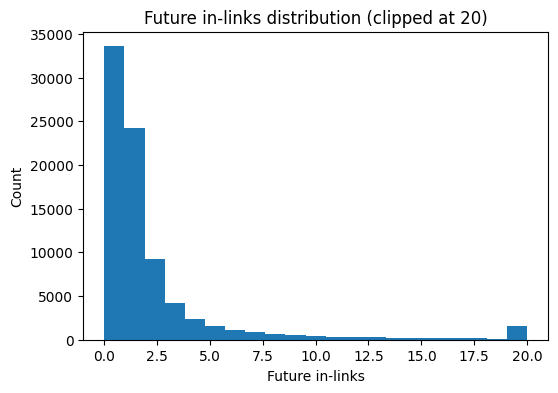

In [4]:
# ============================================================
# 5. EDA 1: Future in-link growth distribution
# ============================================================
# WHY: We need to know whether the outcome is sparse/heavy-tailed before defining RQs or methods.

print(df["future_in_links"].describe())
print("Share of nodes with zero future in-links:", (df["future_in_links"] == 0).mean())

plt.figure(figsize=(6,4))
plt.hist(df["future_in_links"].clip(upper=20), bins=21)
plt.title("Future in-links distribution (clipped at 20)")
plt.xlabel("Future in-links")
plt.ylabel("Count")
plt.show()

,feature,spearman_with_future_in_links
0,PageRank,0.184281
1,In-degree,0.433318
2,Out-degree,0.525415
3,Hub score,0.519585
4,Authority score,0.445390


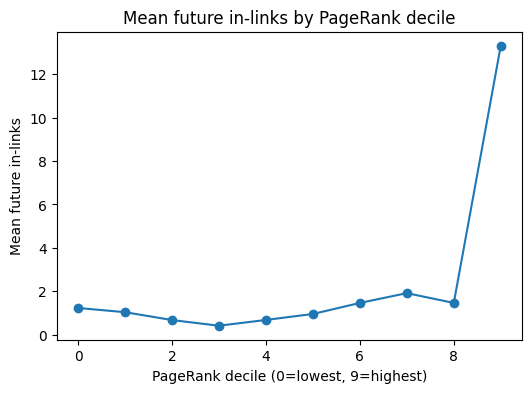

,pr_decile,future_in_links
0,0,1.223804
1,1,1.030303
2,2,0.667762
3,3,0.406037
4,4,0.672265
5,5,0.948035
6,6,1.456426
7,7,1.907996
8,8,1.457345
9,9,13.315687


In [5]:
# ============================================================
# 6. EDA 2: How do centrality measures relate to future growth?
# ============================================================
# WHY: If centrality has no relationship to future link growth, that weakens several candidate RQs.

corr_df = pd.DataFrame([
    ("PageRank", df["pagerank"].corr(df["future_in_links"], method="spearman")),
    ("In-degree", df["in_tr"].corr(df["future_in_links"], method="spearman")),
    ("Out-degree", df["out_tr"].corr(df["future_in_links"], method="spearman")),
    ("Hub score", df["hub_score"].corr(df["future_in_links"], method="spearman")),
    ("Authority score", df["authority_score"].corr(df["future_in_links"], method="spearman")),
], columns=["feature", "spearman_with_future_in_links"])

display(corr_df)

# Decile plot for PageRank
df["pr_decile"] = pd.qcut(df["pagerank"].rank(method="first"), q=10, labels=False)
decile_summary = df.groupby("pr_decile")["future_in_links"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.plot(decile_summary["pr_decile"], decile_summary["future_in_links"], marker="o")
plt.title("Mean future in-links by PageRank decile")
plt.xlabel("PageRank decile (0=lowest, 9=highest)")
plt.ylabel("Mean future in-links")
plt.show()

decile_summary

,mean,median,count
in_giant_scc,,,
0,0.666053,0.0,10861
1,2.558781,1.0,71307


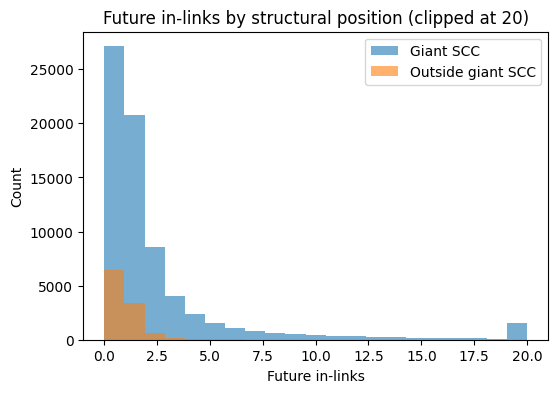

In [6]:
# ============================================================
# 7. EDA 3: Structural position (core vs periphery)
# ============================================================
# WHY: This helps motivate structure-sensitive questions, not just node-level centrality questions.

sccs = list(nx.strongly_connected_components(G))
giant_scc = max(sccs, key=len)
df["in_giant_scc"] = df.index.isin(giant_scc).astype(int)

group_summary = df.groupby("in_giant_scc")["future_in_links"].agg(["mean", "median", "count"])
display(group_summary)

plt.figure(figsize=(6,4))
plt.hist(df.loc[df["in_giant_scc"] == 1, "future_in_links"].clip(upper=20), bins=21, alpha=0.6, label="Giant SCC")
plt.hist(df.loc[df["in_giant_scc"] == 0, "future_in_links"].clip(upper=20), bins=21, alpha=0.6, label="Outside giant SCC")
plt.title("Future in-links by structural position (clipped at 20)")
plt.xlabel("Future in-links")
plt.ylabel("Count")
plt.legend()
plt.show()

Treatment proportion: 0.10000243403758154
Treated group size: 8217
Control group size: 73951
count    82168.000000
mean         0.099999
std          0.213901
min          0.001000
25%          0.007169
50%          0.013647
75%          0.056184
max          0.999000
dtype: float64


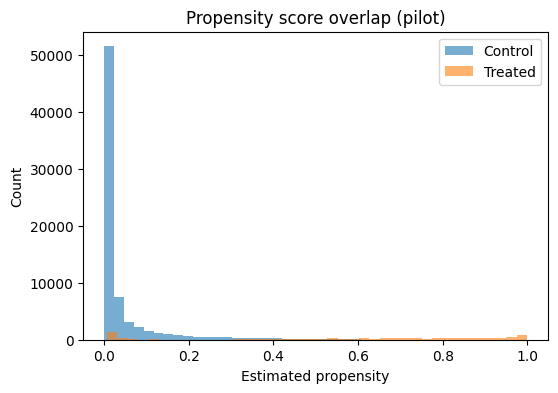

In [7]:
# ============================================================
# 8. EDA 4: Feasibility check for external causal method
# ============================================================
# WHY: Checkpoint 2 asks for additional feasibility work.
# Here we test whether a basic treatment definition is workable.

# Treatment = top 10% PageRank in train graph
thr = df["pagerank"].quantile(0.90)
df["T_highPR"] = (df["pagerank"] >= thr).astype(int)

# Simple covariates for adjustment
df["log_in_tr"] = np.log1p(df["in_tr"])
df["log_out_tr"] = np.log1p(df["out_tr"])
df["log_future_in_links"] = np.log1p(df["future_in_links"])

print("Treatment proportion:", df["T_highPR"].mean())
print("Treated group size:", int(df["T_highPR"].sum()))
print("Control group size:", int((1 - df["T_highPR"]).sum()))

# Quick overlap / propensity pilot
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X_cols = ["log_in_tr", "log_out_tr"]
X = df[X_cols].values
T = df["T_highPR"].values

prop_model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("lr", LogisticRegression(max_iter=300))
])
prop_model.fit(X, T)
p = prop_model.predict_proba(X)[:, 1]
p = np.clip(p, 1e-3, 1 - 1e-3)

print(pd.Series(p).describe())

plt.figure(figsize=(6,4))
plt.hist(p[T == 0], bins=40, alpha=0.6, label="Control")
plt.hist(p[T == 1], bins=40, alpha=0.6, label="Treated")
plt.title("Propensity score overlap (pilot)")
plt.xlabel("Estimated propensity")
plt.ylabel("Count")
plt.legend()
plt.show()

---

## 3. Research Question Definition

Below are **three research questions** motivated by the dataset and additional EDA.

- **At least two use course techniques**
- **At least one uses an external technique**


### RQ1 (Course Technique)
**How well do course centrality measures (PageRank, in-degree, authority score, hub score) identify nodes that later gain incoming links?**

- **Data mining task type:** Graph ranking / centrality analysis  
- **Relevant algorithm(s):**
  - PageRank *(course)*
  - HITS *(course)*
  - Degree-based baselines *(course)*
- **Evaluation criteria:**
  - Spearman correlation with future in-link growth
  - Top-k precision / recall against high-growth nodes
  - Interpretability of rankings

**Why this question matters:**  
The additional EDA shows a clear monotonic increase in mean future in-links across PageRank deciles, suggesting that centrality may carry predictive signal.

**Why it is non-trivial:**  
Different centrality measures capture different structural roles. A strong PageRank signal does not guarantee HITS or degree behaves the same way.

**Feasibility:**  
All required algorithms are already supported in NetworkX and worked successfully in preliminary runs.


### RQ2 (Course Technique)
**How does structural position in the graph (giant SCC membership, reciprocity-related structure, and local connectivity) relate to future in-link growth?**

- **Data mining task type:** Connectivity / structure analysis / group comparison  
- **Relevant algorithm(s):**
  - SCC / WCC decomposition *(course)*
  - Reciprocity analysis *(course)*
  - Clustering coefficient *(course-adjacent graph analysis)*
- **Evaluation criteria:**
  - Mean/median future in-links by structural group
  - Distributional comparisons
  - Interpretability of core vs periphery differences

**Why this question matters:**  
Checkpoint-1 EDA showed a giant SCC core and high reciprocity. That suggests growth may depend not only on node-level centrality, but also on being embedded in the network core.

**Why it is non-trivial:**  
Course centrality methods alone focus on node ranking and may miss structural context.

**Feasibility:**  
Connectivity and reciprocity statistics are already computed and tractable on this dataset.


### RQ3 (External Technique)
**After adjusting for observed structural confounding, what is the estimated effect of being a high-PageRank node on future incoming link growth?**

- **Data mining task type:** Causal effect estimation on observational network data  
- **Relevant algorithm(s):**
  - Propensity score weighting *(external)*
  - Regression adjustment *(external / beyond course)*
  - Optional future extension: doubly robust estimation *(external)*
- **Evaluation criteria:**
  - Naive vs adjusted effect size
  - Overlap diagnostics (propensity score distributions)
  - Stability across adjustment methods
  - Assumption transparency

**Why this question matters:**  
The naive association between PageRank and future growth is strong, but the pilot adjustment suggests the estimate may shrink or behave differently after controlling for past degree.

**Why it is non-trivial:**  
Observational graph data is strongly confounded. High-PageRank nodes are usually already high-degree nodes.

**Feasibility:**  
A pilot propensity model already ran successfully, and treated/control overlap exists, although the external method will require careful sensitivity checking.


---

## 4. RQ-to-Method Mapping Table


| RQ | Task type | Course or external? | Algorithms | Evaluation criteria |
|---|---|---|---|---|
| **RQ1**: Centrality vs future growth | Graph ranking / predictive centrality analysis | **Course** | PageRank, HITS, degree baselines | Spearman correlation, top-k precision/recall, interpretability |
| **RQ2**: Structural position vs growth | Connectivity / structural comparison | **Course** | SCC/WCC, reciprocity, clustering coefficient | Group summaries, distributional differences, interpretability |
| **RQ3**: Adjusted effect of high PageRank | Causal effect estimation | **External** | Propensity score weighting, regression adjustment, possible doubly robust estimator | Effect size, overlap diagnostics, stability across estimators |


---

## 5. Motivation and Feasibility

### Motivation from EDA
The additional EDA revealed three important patterns:

1. **Future in-link growth is sparse but non-trivial.**  
   Most nodes gain no new incoming links in the held-out edges, but a non-negligible subset gains many.

2. **Centrality is clearly related to future growth in naive descriptive analyses.**  
   The PageRank decile plot shows a strong increase in mean future in-links across deciles, although the top decile may be influenced by a relatively small number of highly active nodes.

3. **Core structure may matter.**  
   Nodes in the giant SCC show different growth behavior than nodes outside it.

These patterns motivate questions that go beyond “which nodes are central?” and toward “what kinds of structure predict future growth?” and “does the apparent advantage of centrality survive adjustment?”

### Feasibility
- **Course methods** are straightforward and already tested on this graph.
- **External method** is feasible because:
  - treatment groups exist,
  - the outcome is measurable,
  - propensity overlap is imperfect but present,
  - and pilot code runs successfully.
- At the same time, the propensity score distributions show **limited overlap in some regions**, so causal estimates should be interpreted cautiously and may require trimming, matching, or doubly robust estimation in later checkpoints.

### Risks
- No true timestamps: train/test split is only a pseudo-temporal approximation.
- Heavy-tailed outcomes can make estimates unstable.
- Observational confounding is unavoidable and must be stated clearly.


---

## 6. Methodological Planning

### Course Algorithms
- PageRank
- HITS
- Degree-based baselines
- SCC / WCC decomposition
- Reciprocity and clustering summaries

### External Algorithms
- Propensity score weighting
- Regression adjustment
- Possible future extension: doubly robust estimation

### Baselines
- In-degree as the simplest structural popularity baseline
- Naive difference in means for centrality treatment
- Group comparisons without adjustment (core vs periphery)

### Metrics / Evaluation Plan
- Correlation with future in-link growth
- Top-k retrieval quality for growth nodes
- Group mean / median comparisons
- Overlap diagnostics for causal adjustment
- Stability of adjusted estimates across methods

### Why this plan is appropriate
This plan directly connects the project to course material while also adding a clear beyond-course method. It keeps the project ambitious but still feasible on the available dataset and computing environment.


In [8]:
# ============================================================
# 9. Initial method runs (Checkpoint-2 feasibility demonstration)
# ============================================================
# WHY: The assignment explicitly allows/encourages initial method runs to verify feasibility.

# RQ1 pilot: top-k precision for future-growth nodes
k = int(0.01 * len(df))  # top 1% nodes
growth_threshold = df["future_in_links"].quantile(0.99)
high_growth = set(df.index[df["future_in_links"] >= growth_threshold])

def precision_at_k(score_series, k, target_set):
    top_nodes = set(score_series.sort_values(ascending=False).head(k).index)
    return len(top_nodes & target_set) / k

pilot_metrics = pd.DataFrame([
    ("PageRank", precision_at_k(df["pagerank"], k, high_growth)),
    ("In-degree", precision_at_k(df["in_tr"], k, high_growth)),
    ("Authority", precision_at_k(df["authority_score"], k, high_growth)),
    ("Hub", precision_at_k(df["hub_score"], k, high_growth)),
], columns=["method", "precision_at_top1pct_for_high_growth_nodes"])

display(pilot_metrics)

# RQ3 pilot: naive vs adjusted effect
Y = df["log_future_in_links"].values
w1 = T / p
w0 = (1 - T) / (1 - p)
ate_ipw = (np.sum(w1 * Y) / np.sum(w1)) - (np.sum(w0 * Y) / np.sum(w0))
naive = Y[T == 1].mean() - Y[T == 0].mean()

print("Naive log-outcome difference:", naive)
print("IPW adjusted effect:", ate_ipw)

,method,precision_at_top1pct_for_high_growth_nodes
0,PageRank,0.852619
1,In-degree,0.891596
2,Authority,0.714982
3,Hub,0.611449


Naive log-outcome difference: 1.481824205381228
IPW adjusted effect: -0.34298456760684465


### Pilot interpretation summary

The initial pilot runs suggest three important patterns:

1. **Naive centrality–growth relationships are strong.**  
   Higher-centrality nodes, especially by in-degree and PageRank, are much more likely to appear among the highest-growth nodes.

2. **Simple degree-based measures are very competitive.**  
   In the pilot retrieval test, **in-degree slightly outperformed PageRank**, which suggests that simpler structural measures may remain strong baselines.

3. **Adjusted estimates are sensitive to assumptions.**  
   The naive difference in log future in-links is strongly positive, while the IPW-adjusted estimate is negative. This divergence indicates that the apparent advantage of high PageRank may be substantially confounded by prior structural position.

These results do **not** justify a strong causal claim yet. Instead, they support the feasibility and importance of asking whether the centrality–growth relationship survives more careful adjustment.


---

## 7. Tests / Sanity Checks

These checks validate that the planned methods are feasible and that the pilot results are numerically valid.


In [9]:
import math

print("Running sanity checks...")

# Basic graph
assert G.number_of_nodes() > 0 and G.number_of_edges() > 0, "Graph is empty."

# Split consistency
assert G_tr.number_of_edges() + G_te.number_of_edges() == G.number_of_edges(), "Edge split mismatch."

# Future outcome exists
assert (df["future_in_links"] >= 0).all(), "Negative future in-links found."

# Treatment feasibility
assert df["T_highPR"].nunique() == 2, "Treatment is degenerate."
assert 0 < df["T_highPR"].mean() < 1, "Treatment proportion invalid."

# Propensity overlap feasibility
assert np.all((p > 0) & (p < 1)), "Propensity scores outside (0,1)."

# Pilot metrics validity
assert pilot_metrics["precision_at_top1pct_for_high_growth_nodes"].between(0, 1).all(), "Precision out of [0,1]."
assert math.isfinite(float(naive)), "Naive effect not finite."
assert math.isfinite(float(ate_ipw)), "IPW effect not finite."

print("All checkpoint-2 sanity checks passed.")


Running sanity checks...
All checkpoint-2 sanity checks passed.


---

## 8. Written RQ Section

### Brief recap
The project uses the directed Slashdot0902 network. Checkpoint-1 EDA showed a sparse graph with heavy-tailed degrees, a giant SCC core, high reciprocity, and strong skew in centrality. Additional EDA for Checkpoint 2 showed that future in-link growth is sparse but measurable, and that higher PageRank deciles tend to gain more future in-links in naive comparisons.

The pilot runs also showed that:
- **in-degree slightly outperformed PageRank** in identifying high-growth nodes,
- the giant SCC appears structurally different from the periphery,
- and naive vs adjusted estimates for the high-PageRank treatment can differ substantially.

### Final research questions
1. **RQ1 (course):** How well do PageRank, HITS, and degree-based centrality measures identify nodes that later gain incoming links?  
2. **RQ2 (course):** How does structural position (giant SCC membership and related graph structure) relate to future in-link growth?  
3. **RQ3 (external):** After adjusting for observed structural confounding, what is the estimated effect of being a high-PageRank node on future incoming link growth?

### Planned contribution
This project combines graph-mining methods from the course with a beyond-course causal estimation framework. The goal is not to make strong causal claims from observational data, but to carefully investigate which structural signals remain informative after adjustment and which apparent effects are mainly driven by confounding.


---

## 9. Takeaways

- The dataset supports **two clear course-based questions** (centrality prediction and structural position) and **one clear beyond-course question** (causal adjustment).
- Additional EDA confirms that the proposed outcome, **future in-link growth**, is both measurable and non-trivial.
- Pilot results show that:
  - high-centrality nodes tend to grow faster in naive analysis,
  - simpler measures like **in-degree** remain strong baselines,
  - and external causal methods are feasible but sensitive to overlap and confounding.

These findings make the proposed research questions both **interesting** and **doable** for the semester project.


---

## 10. GitHub Repository

- https://github.com/jace-1215/CSCE676-Project
